# Phenotype clustering
This notebook present an example of how the The Rapid's `optimize_stepMix()` class already trained can be used to explore results for phenotypes signification and class enumeration.
The grid search was already conducted, and models stored as pickled object.
This code loads this object, and explore results for phenotypes signification and class enumeration.

# check results to define k

## load the trained models

The Rapid's `optimize_stepMix()` class was already trained (grid search conducted) using the method `.gridSearch()`, and stored as picked object

In [1]:
#gs3_lca_1_15_max2000
import pickle
import sys
sys.path.append('./code')
from AdjGridSearch7 import optimize_stepMix
with open('./res/childGridS/gs3_lca_1_15_max2000.pkl', 'rb') as file:
    gridS1_15Child=pickle.load(file)

## Inspect metrics 

The Rapid's `optimize_stepMix()` class present some methods incorporated to enable users to inspect metrics, report the overall results of the gridsearch in graphical manner or export them to .csv files

### Graphical visualization of the fit metrics

The `.summary()` method implements the reporting on the progression of fit metrics to enable decisions on best k.
- log likelihood is ploted alone, alongside indication of convergence or not;
- information criterias (BIC, AIC, SABIC, CAIC) are plotted together, with same indication about convergence or not.
- thought not indicated for use in the decision process, we also add entropy and relative entropy plots

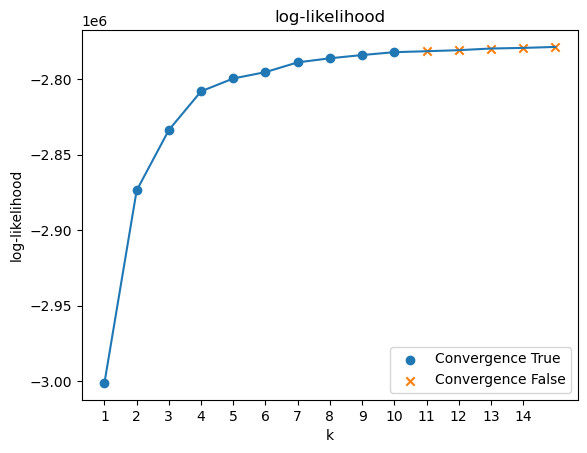

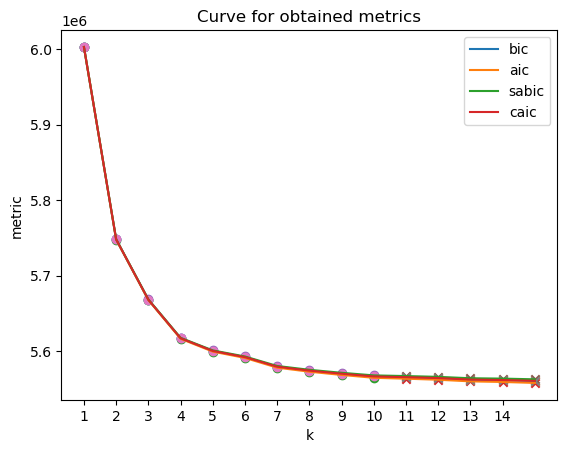

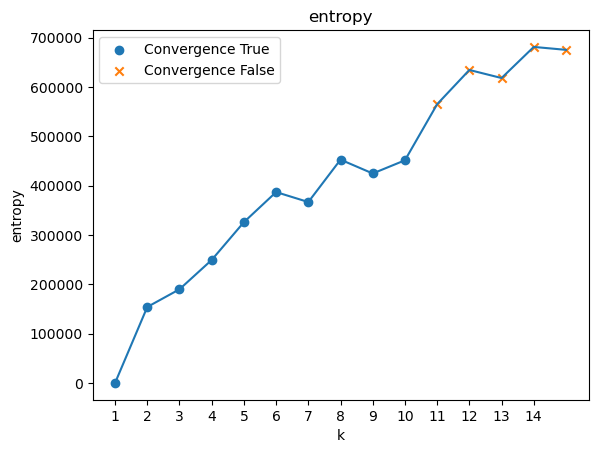

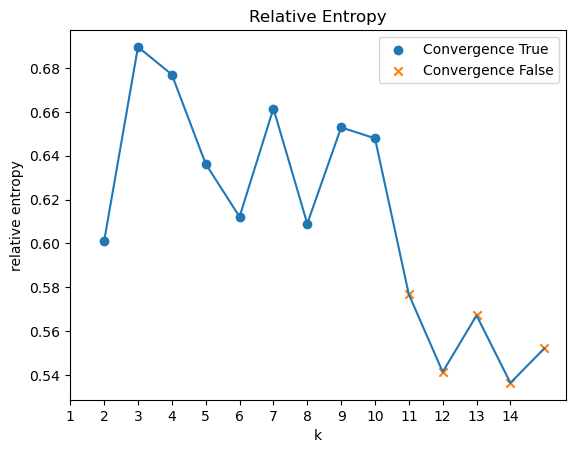

In [3]:
gridS1_15Child.summary(path='./res/childGridS')

### full metrics table

the full metrics table can be acessed as `.nestedModelsLRT` parameter

In [6]:
gridS1_15Child.nestedModelsLRT.columns

Index(['LL', 'score', 'aic', 'bic', 'caic', 'sabic', 'entropy',
       'relative_entropy', 'convergence', 'npar', 'n', 'ncomp', 'dof',
       'log-likelihood diff', 'dof diff', 'p value', 'ave_pp_min', 'occ_k_min',
       'min_mm_f', 'min_class_perc'],
      dtype='object')

### Information criterias

In [8]:
gridS1_15Child.nestedModelsLRT[['aic', 'bic', 'caic', 'sabic']]

,aic,bic,caic,sabic
k,,,,
2,5747661.730837308,5747987.40409223,5748016.40409223,5748278.913890223
3,5667642.3196509555,5668136.444589458,5668180.444589458,5668578.735317447
4,5616473.125376329,5617135.701998412,5617194.701998412,5617728.773656397
5,5599489.814504564,5600320.842810228,5600394.842810228,5601064.695398209
6,5591093.536699968,5592093.016689212,5592182.016689212,5592987.65020719
7,5578220.451774555,5579388.383447379,5579492.383447379,5580433.797895353
8,5572846.691012477,5574183.074368881,5574302.074368881,5575379.269746851
9,5568580.938812911,5570085.773852895,5570219.773852895,5571432.750160862
10,5564801.730891141,5566475.017614706,5566624.017614706,5567972.774852669


### diagnostic metrics

thought not indicated to be used for decision, we consdiered some diagnostic metrics would be interesting.
    - alongside entropy and relative entropy
    - another metric that usually is assessed is Average Posterior Class of Assignment (AvePP), a metric computed per class and sumarized here with its minimum among classes for definition
    - the same applies for Odds of latent class correct classification (OCC), also with minimum stored and reortee
    - minimal symptom frequency (and percentage) is also another usually considered metric, and included

In [9]:
gridS1_15Child.nestedModelsLRT[['entropy', 'relative_entropy','ave_pp_min', 'occ_k_min',
       'min_mm_f', 'min_class_perc']]

,entropy,relative_entropy,ave_pp_min,occ_k_min,min_mm_f,min_class_perc
k,,,,,,
2,154011.53001208702,0.6010090600768567,0.857647,4.026592,0.054760,33.350226
3,189909.2495673814,0.6895891272590049,0.828069,3.990929,0.082991,17.068972
4,249375.0798430214,0.6769774396366063,0.795935,5.978533,0.084184,14.850265
5,326033.66100377997,0.6362328538366799,0.667990,6.498184,0.144502,8.500196
6,387027.09408793336,0.6121204165073426,0.670010,6.360499,0.180819,4.449902
7,366816.58995070803,0.6614978388149176,0.670893,4.499167,0.217782,2.720493
8,452797.05774930515,0.608986150470573,0.633488,4.126233,0.228432,1.853235
9,424730.92877143127,0.6528839469894934,0.598825,4.398599,0.584018,0.183361
10,451491.1179080722,0.6478977648203106,0.549705,4.671000,0.582846,0.178883


#### diagnostic metrics per class
its extraction is not operationalized, but can be extracted from the gridSearch object

In [16]:
k=8
gridS1_15Child.DiagClass['occ_ratios'].loc[:,k]

0     131.483020
1      15.215117
2      13.854233
3      21.547036
4       4.126233
5      27.844060
6      13.220572
7      56.447046
8            NaN
9            NaN
10           NaN
11           NaN
12           NaN
13           NaN
14           NaN
Name: 8, dtype: float64

In [18]:
gridS1_15Child.DiagClass['AvePP'].loc[:,k]

0     0.712866
1     0.710434
2     0.687144
3     0.691290
4     0.723777
5     0.677794
6     0.633488
7     0.686672
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
Name: 8, dtype: float64

### to_csv

the same stats can also be exported to csv

## inspect some alternative ks

The `.describe_k()` method is set to enable quick exploration. 

======================= LCA with k = 8=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                                                        
          class_no               0       1       2       3       4       5       6       7
          param variable                                                                  
          pis   ARTRALGIA   0.3476  0.0181  0.0692  0.0365  0.0343  0.0009  0.2106  0.4153
                ARTRITE     0.3507  0.0115  0.0398  0.0175  0.0036  0.0006  0.1601  0.3952
                CEFALEIA    0.8762  0.4012  0.9080  0.2462  0.8094  0.0050  0.9148  0.9825
                CONJUNTVIT  0.2284  0.0114  0.0445  0.0210  0.0048  0.0000  0.0720  0.1904
                DOR_COSTAS  0.5119  0.0624  0.2850  0.0308  0.0661  0.0043  0.4703  0.8082
                DOR_RETRO   0.5784  0.0412  0.2922  0.0720  0.1733  0.0006  0.5193  0.6596
                EXANTEMA    0.5352  0.0814  0.1475  0.3163  0.0626  0.0

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

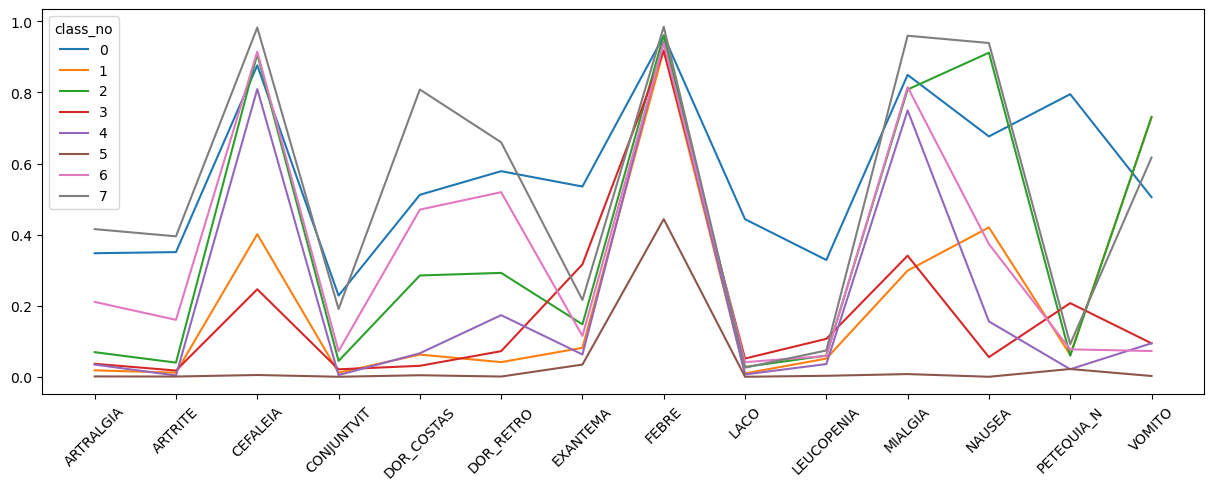

------------------------ predictions ------------------------------


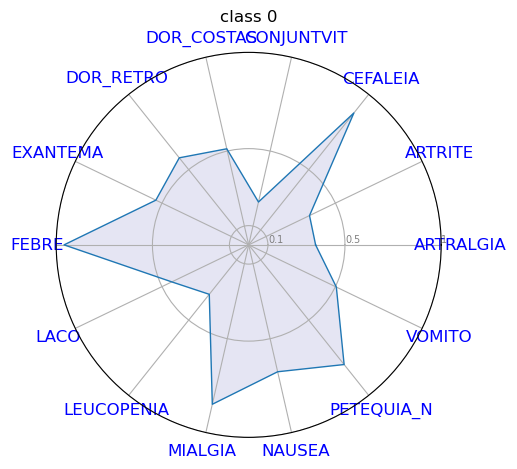

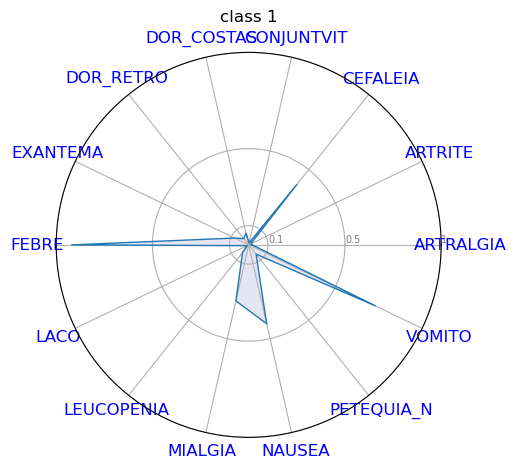

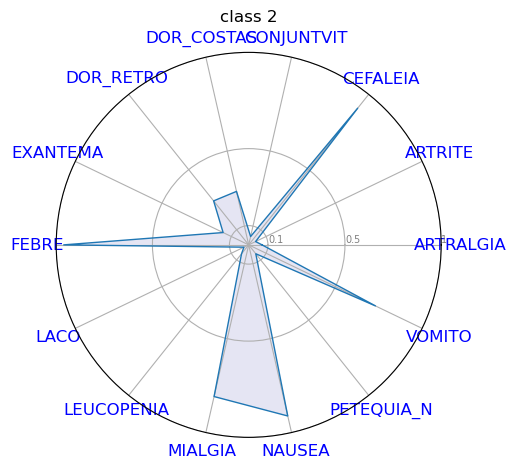

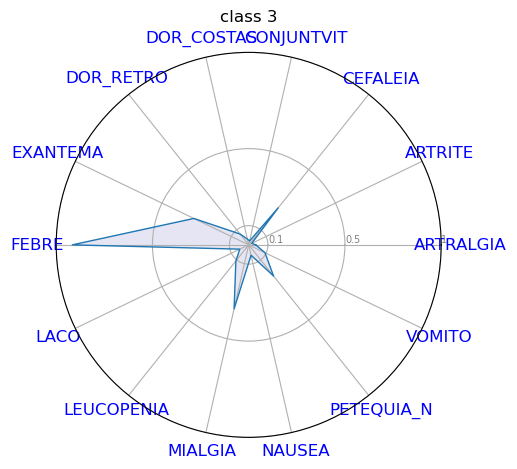

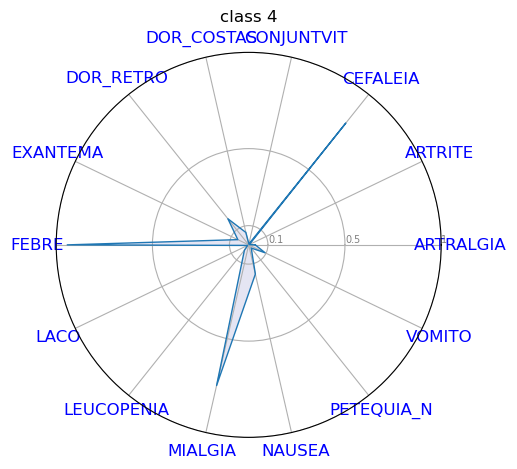

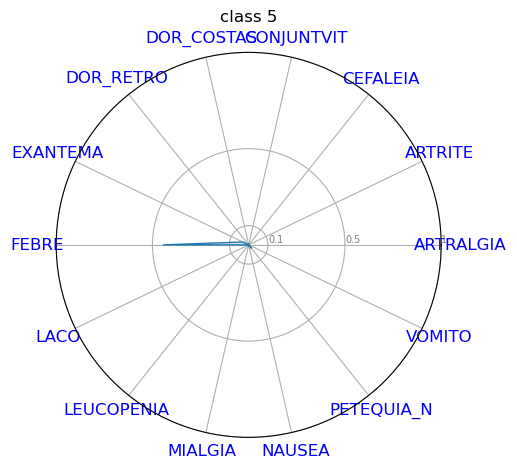

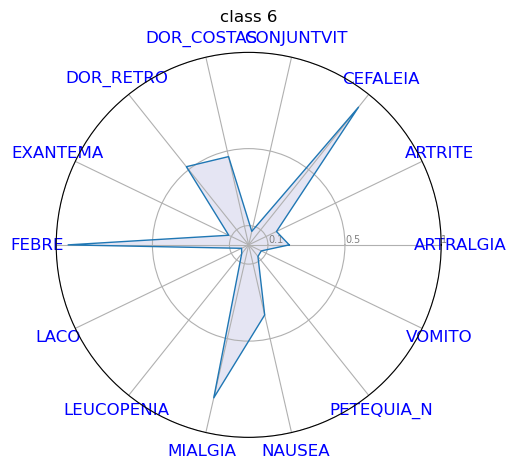

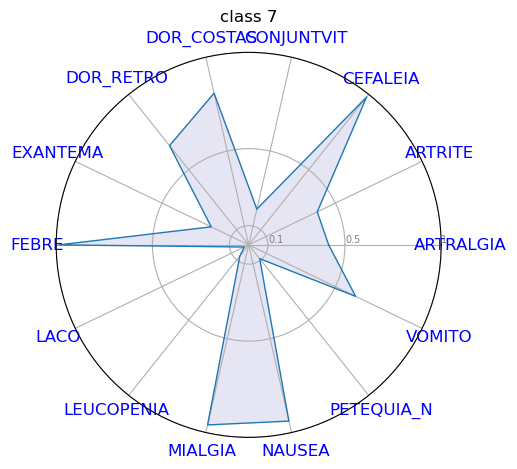

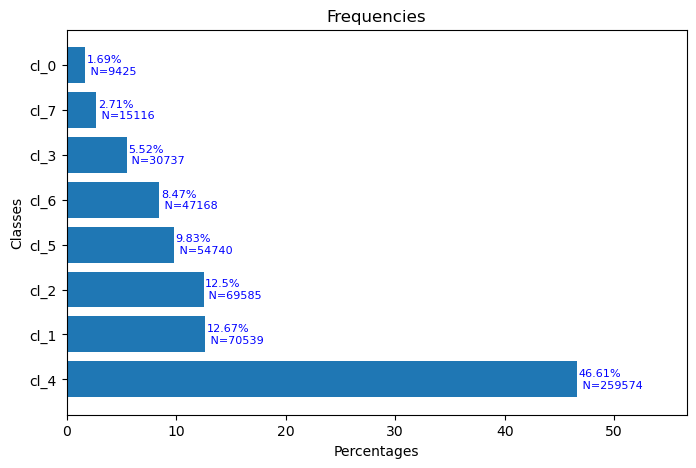

Empty DataFrame
Columns: []
Index: []


In [4]:
gridS1_15Child.describe_k(k=8)

### several alternatives in loop

Sometimes we have no single definition based on the fit metrics, and alternative solutions need to be examined to enable a full discussion of their clinical relevance.
We can easily implement this with a simple for loop, specifying ks, visualising the results, and generating (exporting) reports to files in a specific directory.


======================= LCA with k = 1=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary
          class_no               0
          param variable          
          pis   ARTRALGIA   0.0751
                ARTRITE     0.0499
                CEFALEIA    0.6766
                CONJUNTVIT  0.0312
                DOR_COSTAS  0.1706
                DOR_RETRO   0.2153
                EXANTEMA    0.1193
                FEBRE       0.9057
                LACO        0.0264
                LEUCOPENIA  0.0550
                MIALGIA     0.6216
                NAUSEA      0.3396
                PETEQUIA_N  0.0730
                VOMITO      0.2877
    Class weights
        Class 1 : 1.00
    Fit for 1 latent classes
    Estimation method             : 1-step
    Number of observations        : 556884
    Number of latent classes      : 1
    Number of estimated parameters: 14
    Log-likelihood (LL)           : -3001217.2318
    -2LL    

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

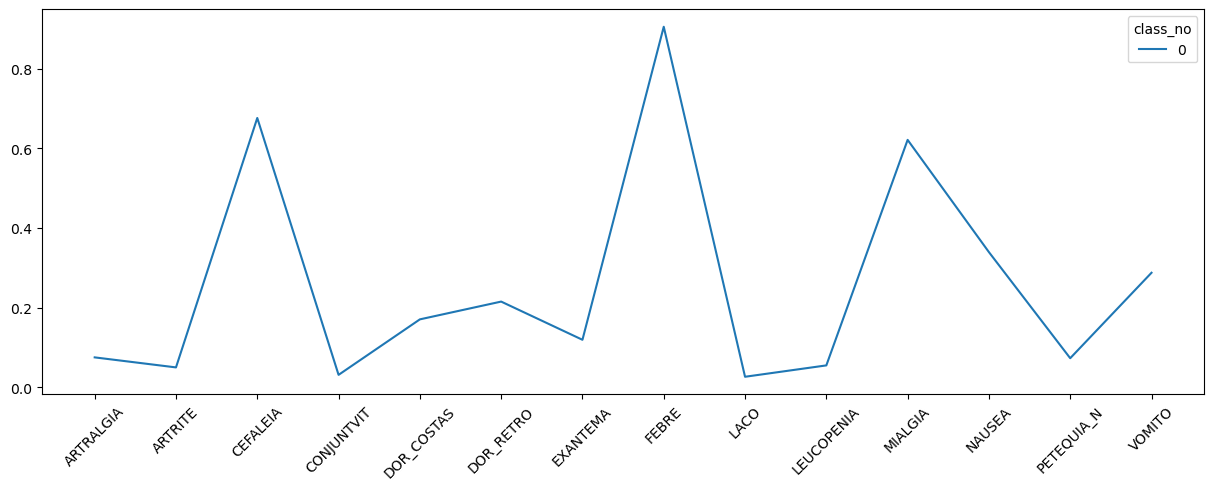

------------------------ predictions ------------------------------


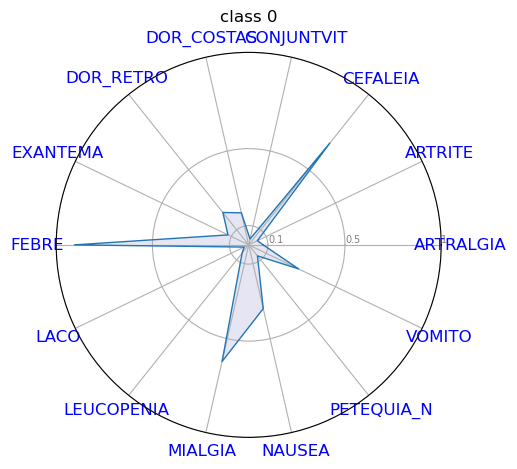

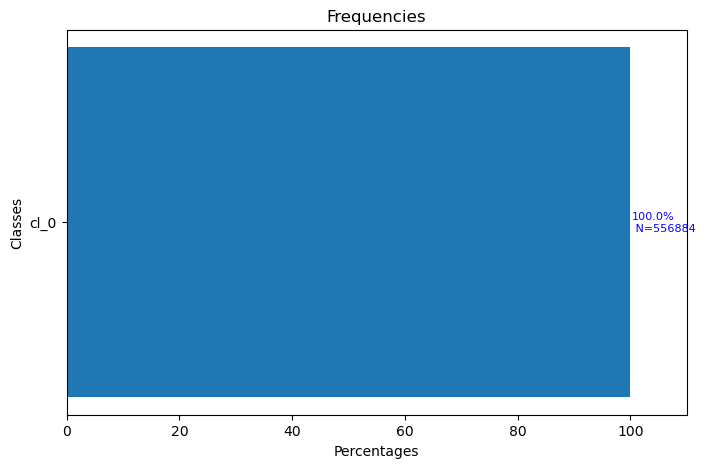

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 2=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary        
          class_no               0       1
          param variable                  
          pis   ARTRALGIA   0.0239  0.1775
                ARTRITE     0.0063  0.1371
                CEFALEIA    0.5481  0.9334
                CONJUNTVIT  0.0070  0.0796
                DOR_COSTAS  0.0461  0.4194
                DOR_RETRO   0.0996  0.4464
                EXANTEMA    0.0984  0.1611
                FEBRE       0.8733  0.9705
                LACO        0.0122  0.0548
                LEUCOPENIA  0.0433  0.0783
                MIALGIA     0.5039  0.8568
                NAUSEA      0.1844  0.6497
                PETEQUIA_N  0.0553  0.1084
                VOMITO      0.2193  0.4245
    Class weights
        Class 1 : 0.67
        Class 2 : 0.33
    Fit for 2 latent classes
    Estimation method       

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

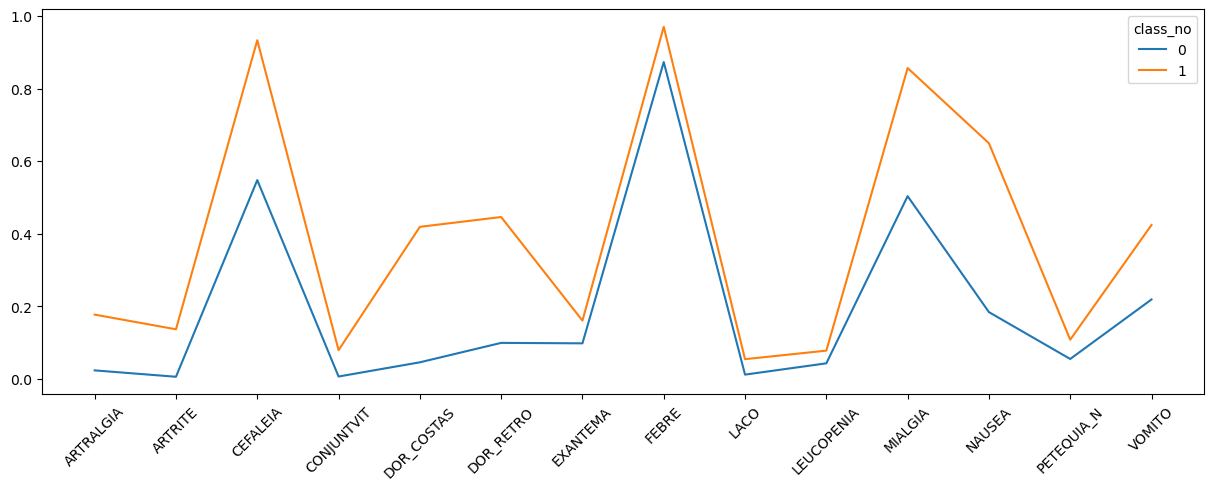

------------------------ predictions ------------------------------


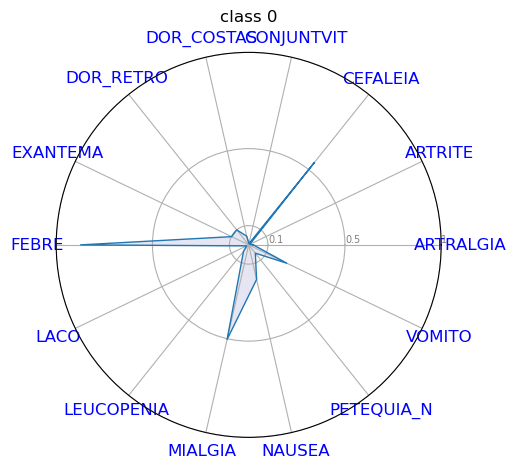

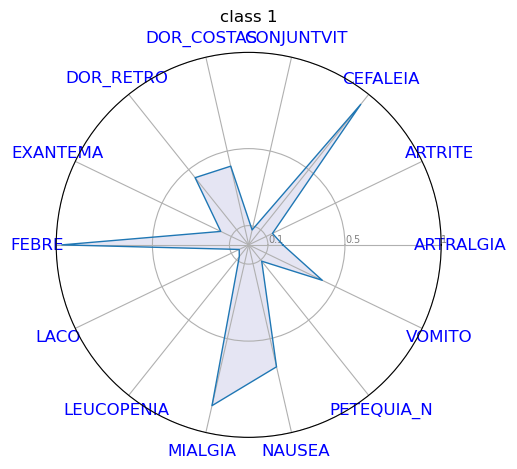

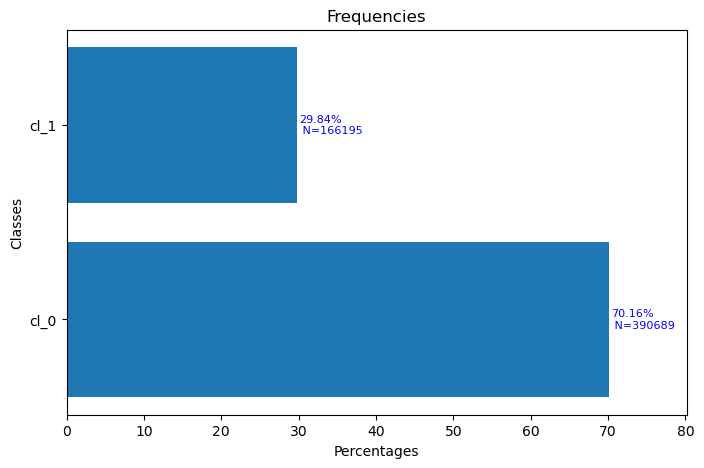

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 3=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                
          class_no               0       1       2
          param variable                          
          pis   ARTRALGIA   0.0087  0.0436  0.2498
                ARTRITE     0.0048  0.0135  0.2219
                CEFALEIA    0.0433  0.7715  0.9331
                CONJUNTVIT  0.0066  0.0113  0.1252
                DOR_COSTAS  0.0126  0.0995  0.5719
                DOR_RETRO   0.0094  0.1828  0.5240
                EXANTEMA    0.1387  0.0866  0.2176
                FEBRE       0.6997  0.9431  0.9659
                LACO        0.0158  0.0133  0.0830
                LEUCOPENIA  0.0432  0.0457  0.0988
                MIALGIA     0.0889  0.6931  0.8669
                NAUSEA      0.1024  0.2829  0.7640
                PETEQUIA_N  0.0930  0.0425  0.1631
                VOMITO      0.2191  

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

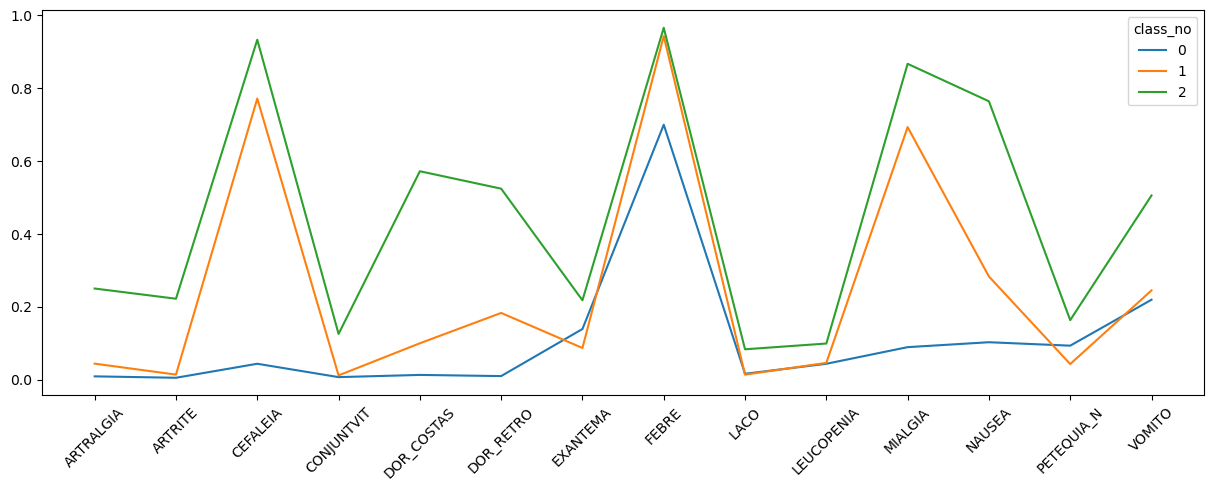

------------------------ predictions ------------------------------


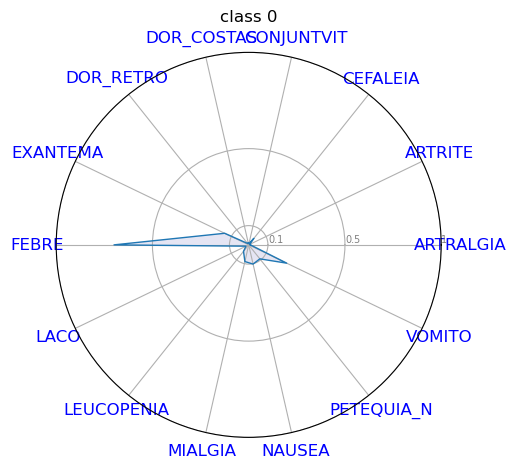

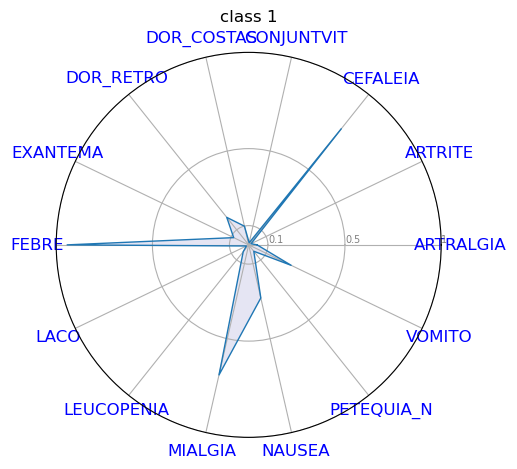

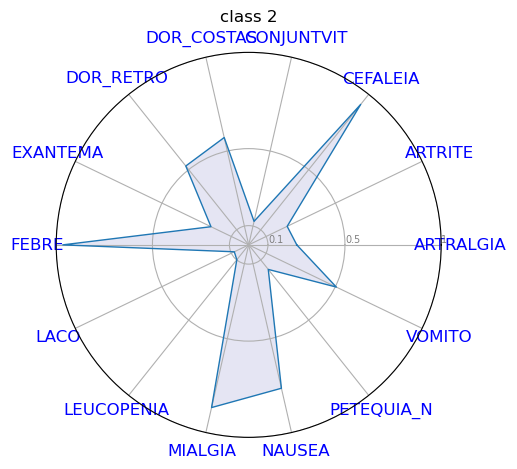

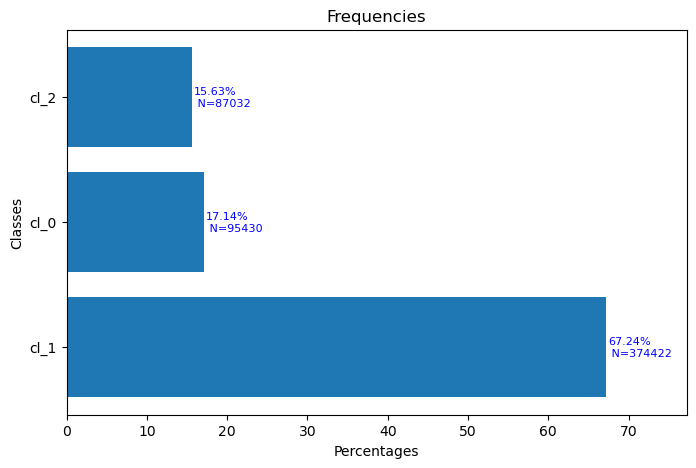

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 4=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                        
          class_no               0       1       2       3
          param variable                                  
          pis   ARTRALGIA   0.0525  0.0080  0.2714  0.0268
                ARTRITE     0.0178  0.0040  0.2375  0.0114
                CEFALEIA    0.7966  0.0436  0.9519  0.6624
                CONJUNTVIT  0.0122  0.0051  0.1300  0.0158
                DOR_COSTAS  0.1058  0.0094  0.5991  0.1011
                DOR_RETRO   0.2089  0.0096  0.5723  0.1160
                EXANTEMA    0.0872  0.1374  0.2151  0.1026
                FEBRE       0.9433  0.6664  0.9666  0.9424
                LACO        0.0152  0.0144  0.0842  0.0156
                LEUCOPENIA  0.0448  0.0386  0.0991  0.0539
                MIALGIA     0.7417  0.0787  0.8960  0.5541
                NAUSEA    

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

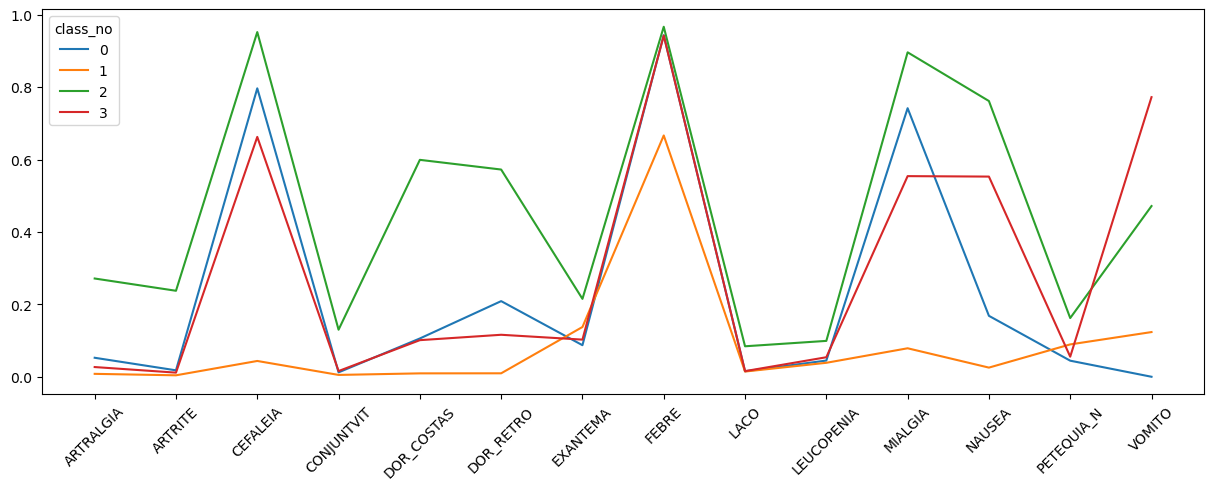

------------------------ predictions ------------------------------


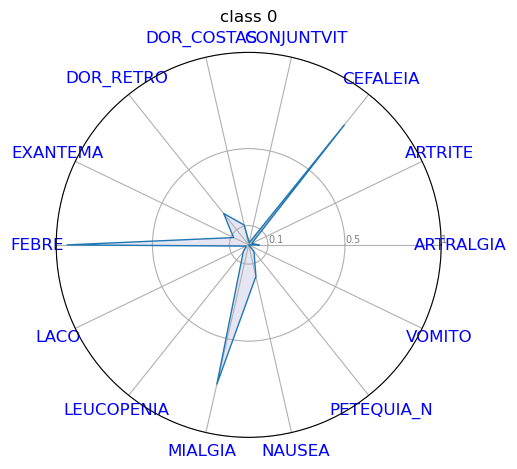

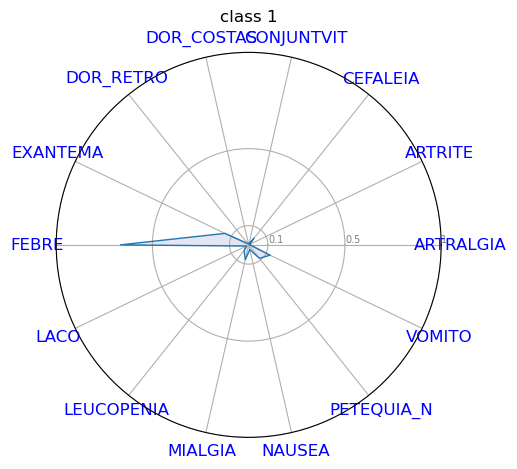

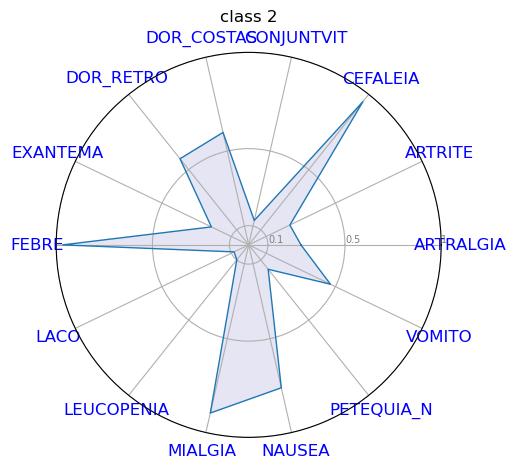

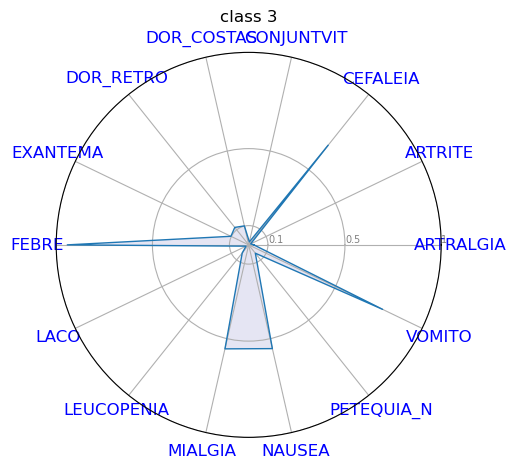

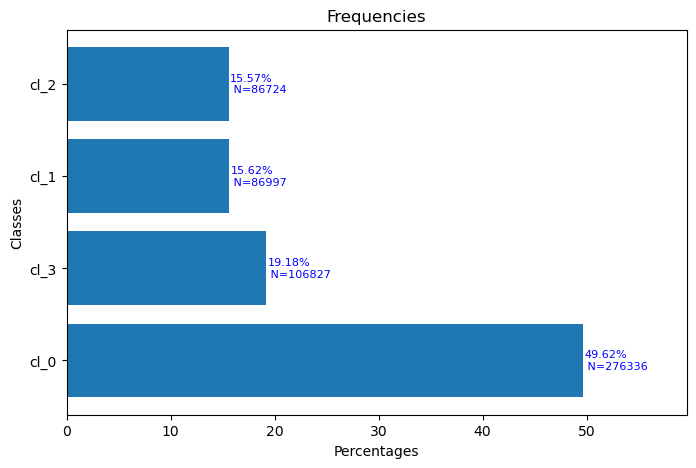

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 6=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                                        
          class_no               0       1       2       3       4       5
          param variable                                                  
          pis   ARTRALGIA   0.0224  0.1090  0.0060  0.0360  0.2318  0.4164
                ARTRITE     0.0121  0.0688  0.0031  0.0041  0.1870  0.4154
                CEFALEIA    0.4633  0.9556  0.0264  0.7898  0.8473  0.9398
                CONJUNTVIT  0.0165  0.0458  0.0032  0.0054  0.0817  0.2394
                DOR_COSTAS  0.0620  0.3711  0.0075  0.0680  0.4271  0.6909
                DOR_RETRO   0.0629  0.3803  0.0079  0.1744  0.5012  0.6341
                EXANTEMA    0.1235  0.1022  0.1280  0.0779  0.1854  0.3778
                FEBRE       0.9293  0.9563  0.5923  0.9467  0.9321  0.9770
                LACO       

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

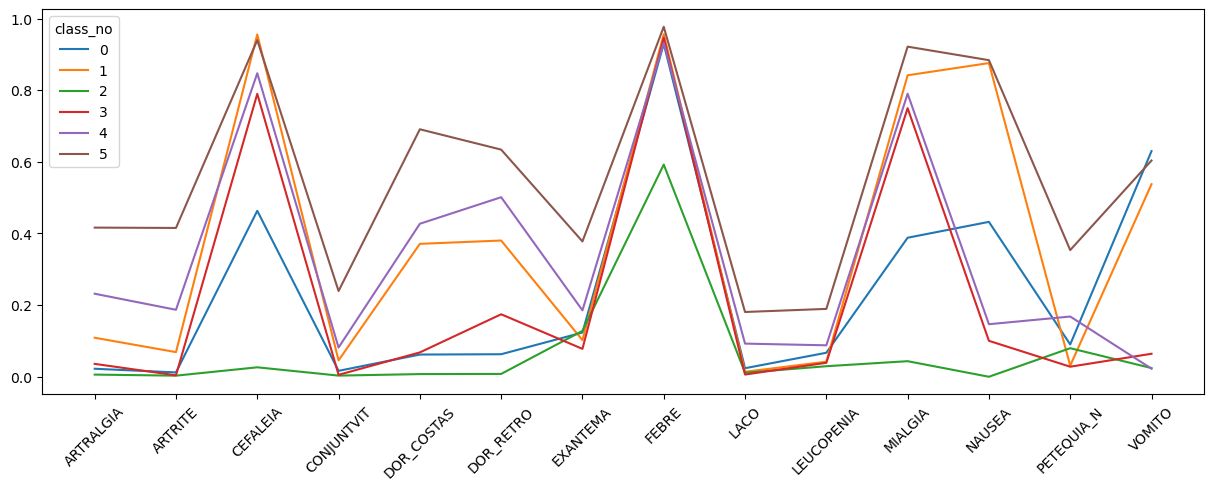

------------------------ predictions ------------------------------


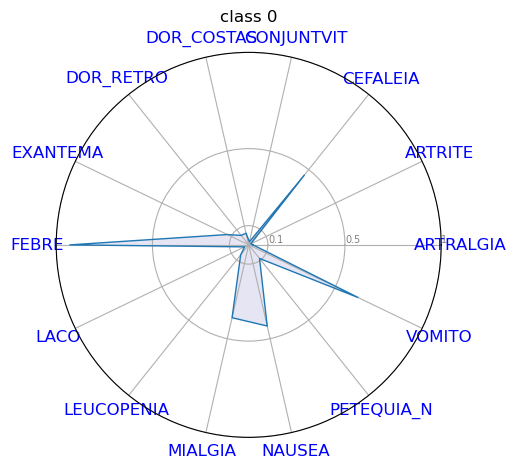

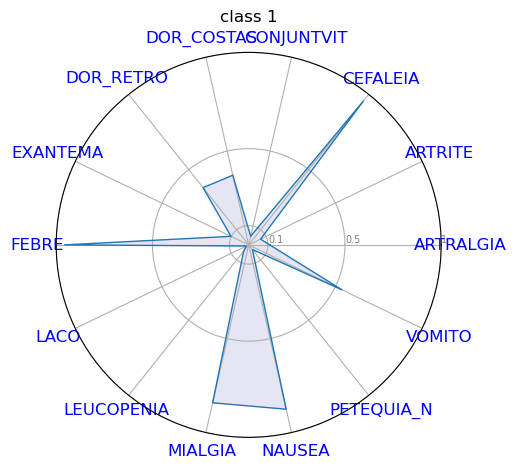

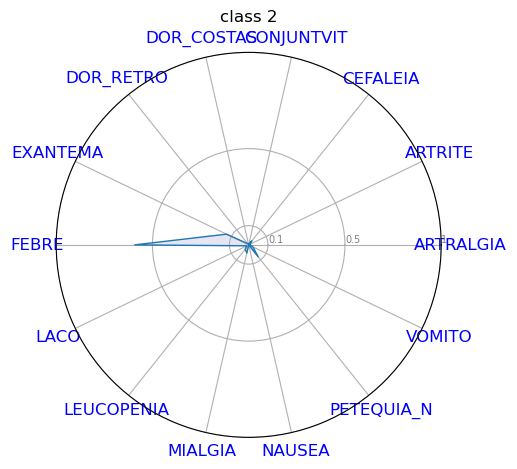

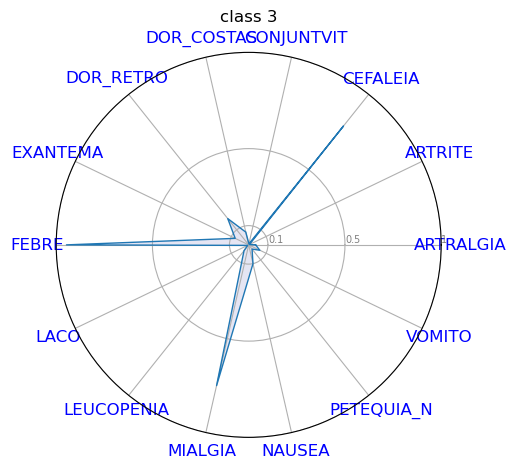

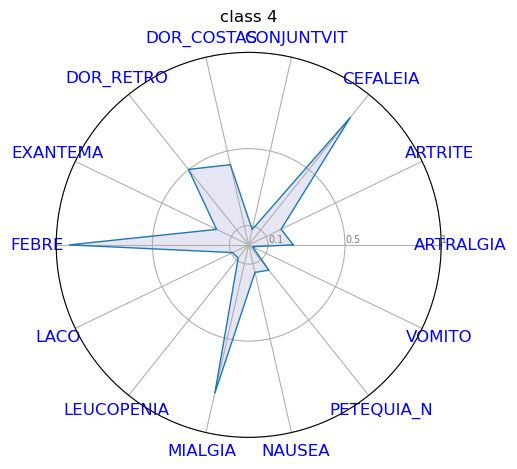

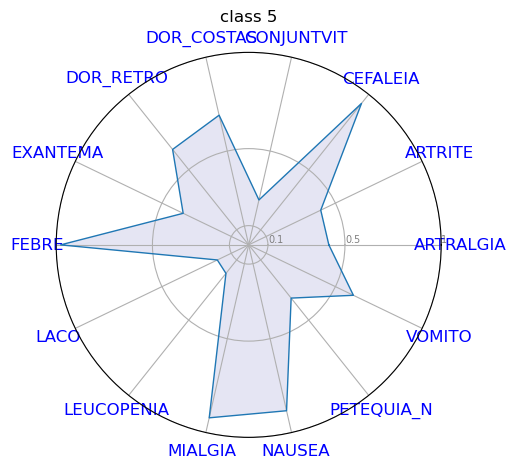

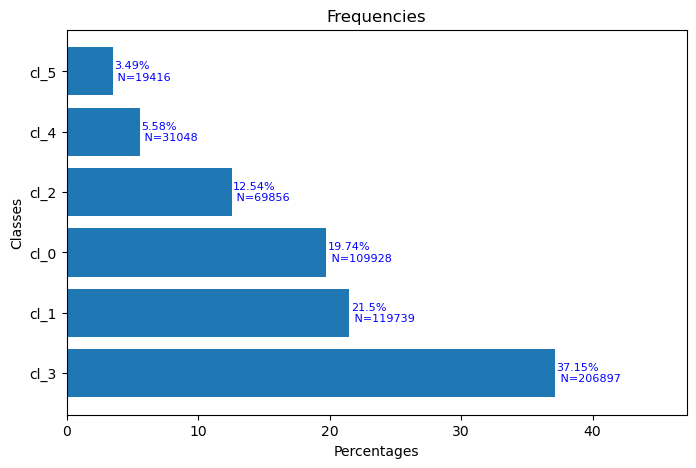

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 7=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                                                
          class_no               0       1       2       3       4       5       6
          param variable                                                          
          pis   ARTRALGIA   0.0161  0.3385  0.3258  0.0007  0.0810  0.0319  0.0486
                ARTRITE     0.0094  0.3384  0.2914  0.0005  0.0506  0.0155  0.0141
                CEFALEIA    0.4246  0.8814  0.9632  0.0058  0.9205  0.1905  0.8199
                CONJUNTVIT  0.0112  0.2178  0.1281  0.0000  0.0523  0.0185  0.0106
                DOR_COSTAS  0.0614  0.5229  0.7061  0.0033  0.3155  0.0271  0.1016
                DOR_RETRO   0.0422  0.5702  0.6307  0.0003  0.3084  0.0571  0.2087
                EXANTEMA    0.0809  0.4991  0.1400  0.0289  0.1612  0.3132  0.0718
                FEBRE 

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

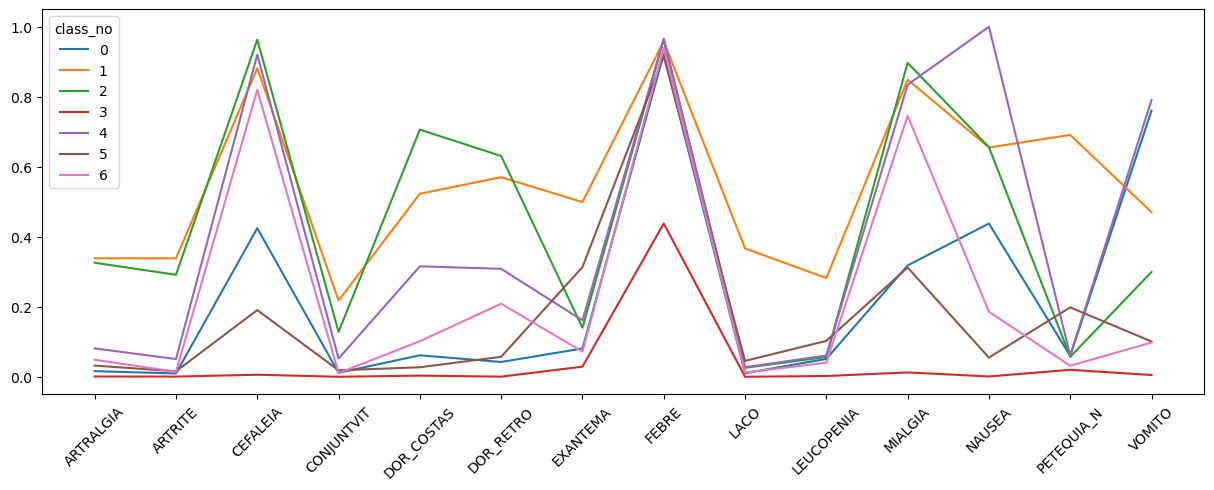

------------------------ predictions ------------------------------


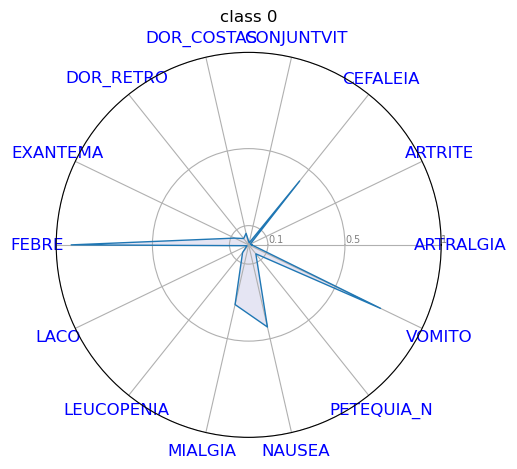

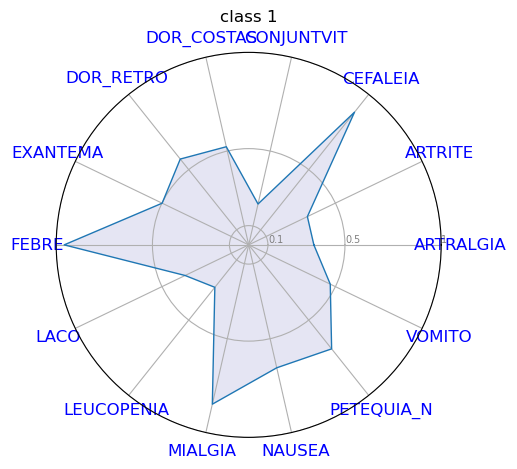

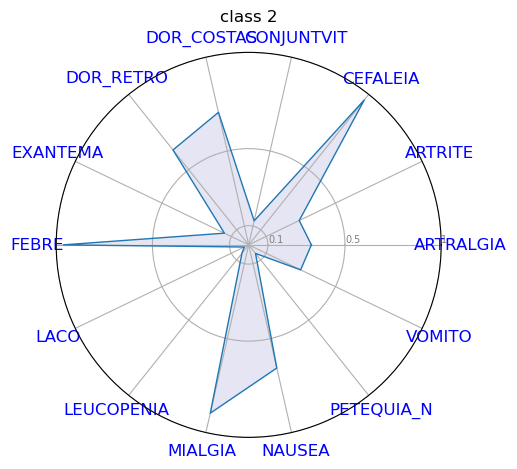

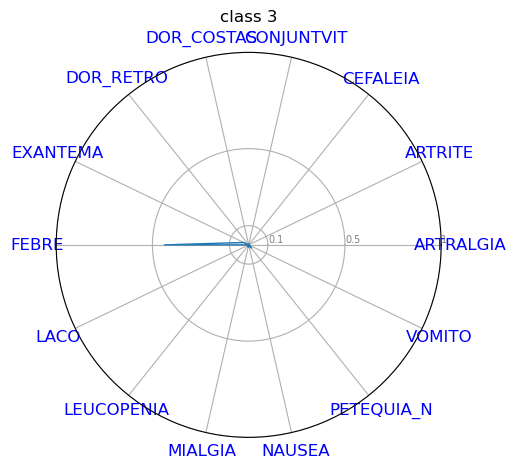

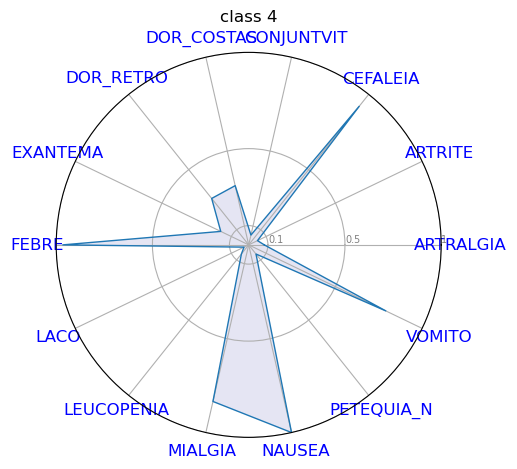

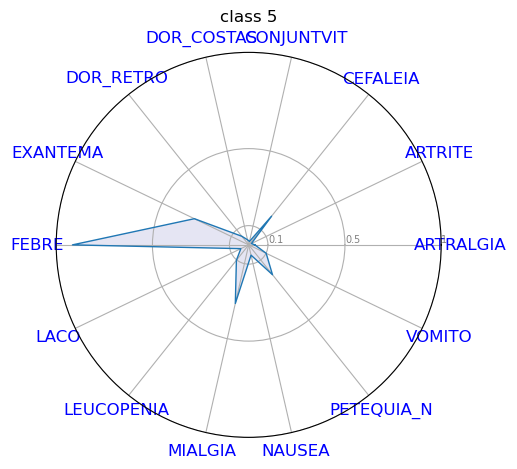

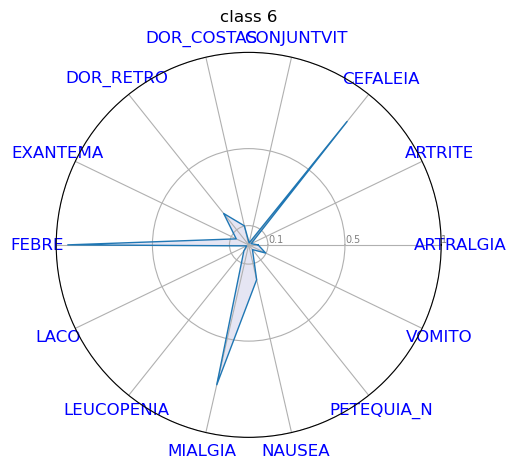

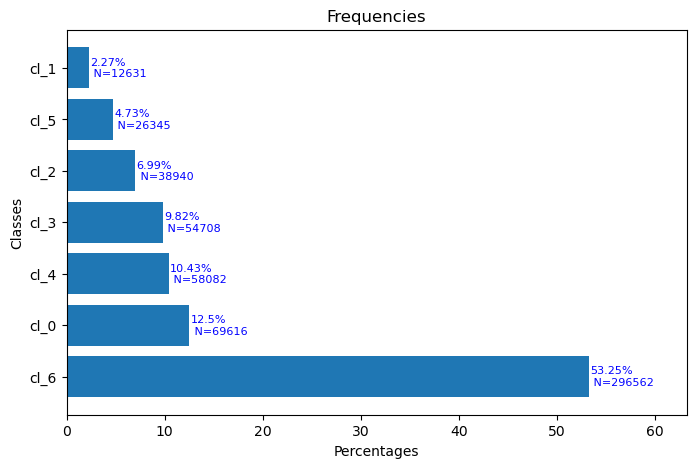

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 8=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                                                        
          class_no               0       1       2       3       4       5       6       7
          param variable                                                                  
          pis   ARTRALGIA   0.3476  0.0181  0.0692  0.0365  0.0343  0.0009  0.2106  0.4153
                ARTRITE     0.3507  0.0115  0.0398  0.0175  0.0036  0.0006  0.1601  0.3952
                CEFALEIA    0.8762  0.4012  0.9080  0.2462  0.8094  0.0050  0.9148  0.9825
                CONJUNTVIT  0.2284  0.0114  0.0445  0.0210  0.0048  0.0000  0.0720  0.1904
                DOR_COSTAS  0.5119  0.0624  0.2850  0.0308  0.0661  0.0043  0.4703  0.8082
                DOR_RETRO   0.5784  0.0412  0.2922  0.0720  0.1733  0.0006  0.5193  0.6596
                EXANTEMA    0.535

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

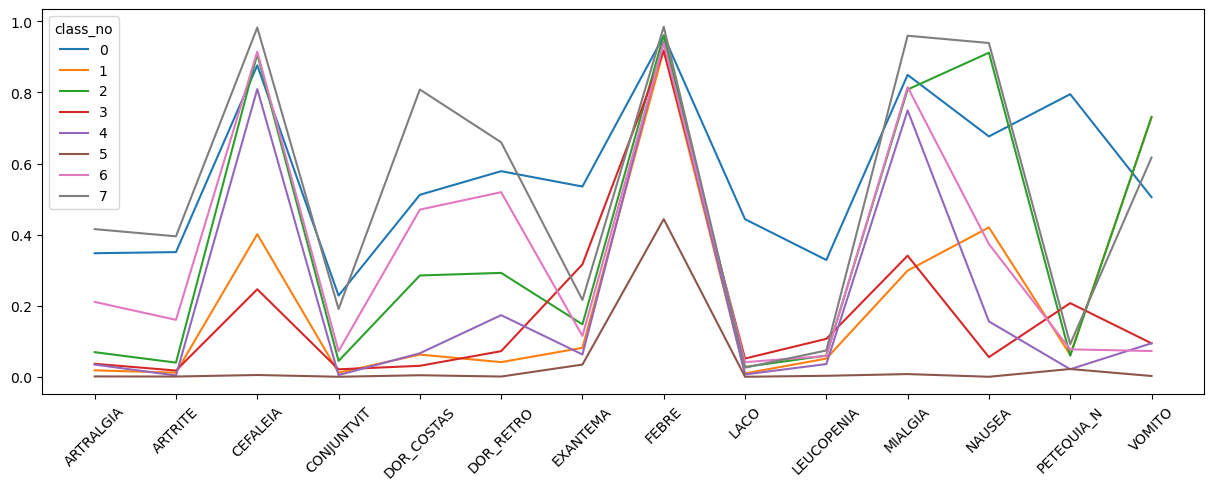

------------------------ predictions ------------------------------


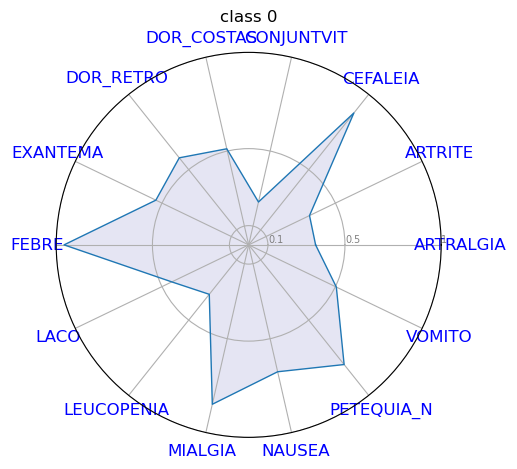

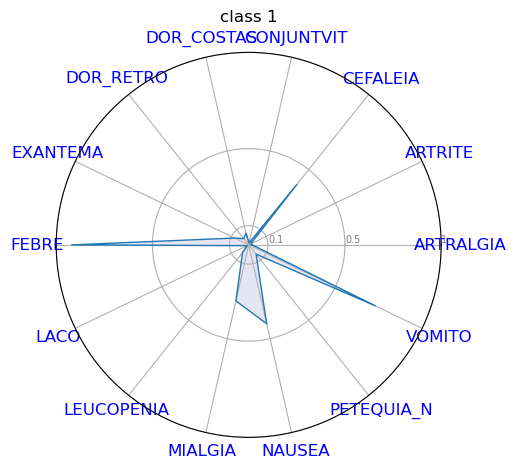

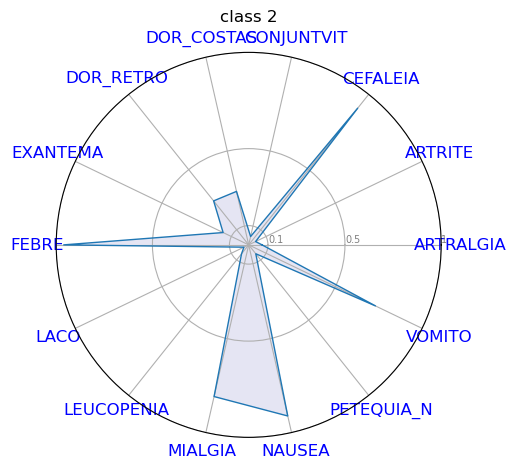

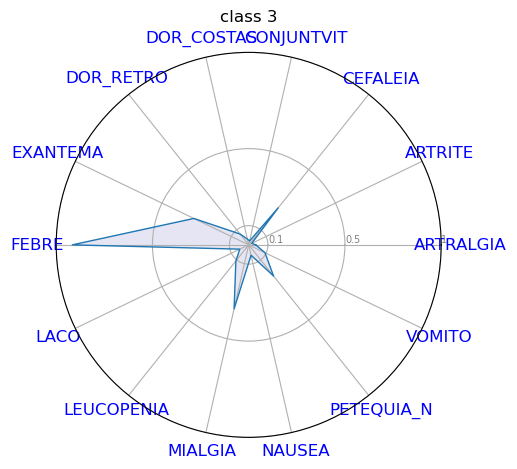

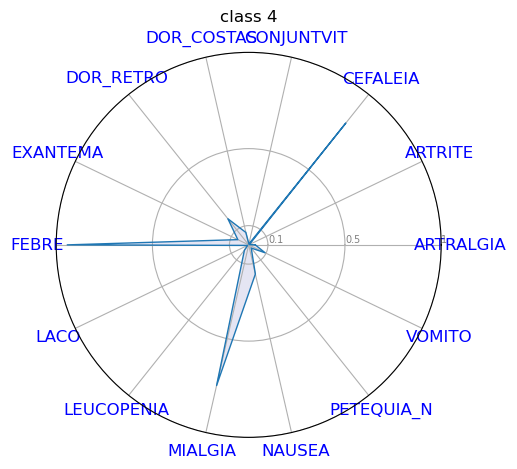

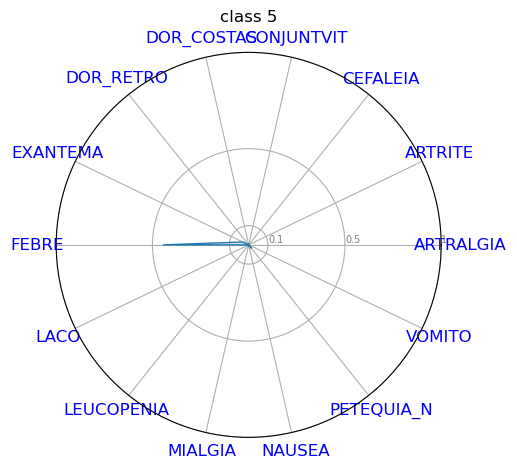

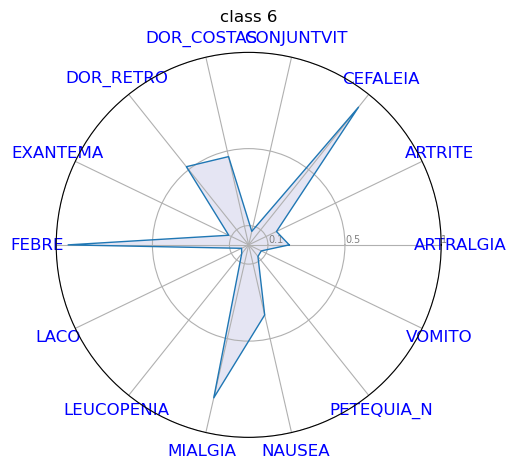

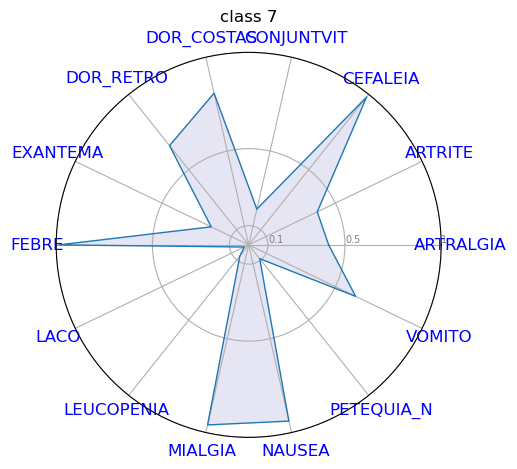

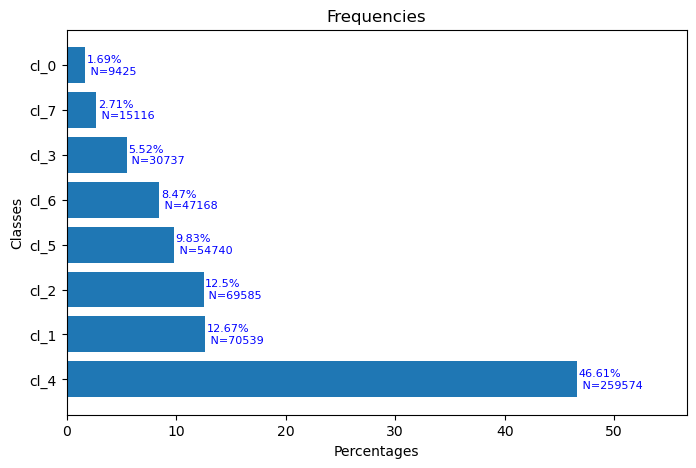

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 9=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                                                                
          class_no               0       1       2       3       4       5       6       7       8
          param variable                                                                          
          pis   ARTRALGIA   0.1575  0.2590  0.4307  0.0292  0.0181  0.0399  0.0728  0.9347  0.0002
                ARTRITE     0.1465  0.2090  0.4304  0.0135  0.0116  0.0077  0.0400  0.9297  0.0003
                CEFALEIA    0.8154  0.9342  0.9764  0.1452  0.4087  0.8123  0.9195  0.8564  0.0022
                CONJUNTVIT  0.1011  0.0904  0.2173  0.0151  0.0125  0.0074  0.0441  0.7354  0.0000
                DOR_COSTAS  0.2947  0.5781  0.7973  0.0246  0.0637  0.0773  0.3001  0.8553  0.0028
                DOR_RETRO   0.4306  0.5754  0.6428  0.0466  

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

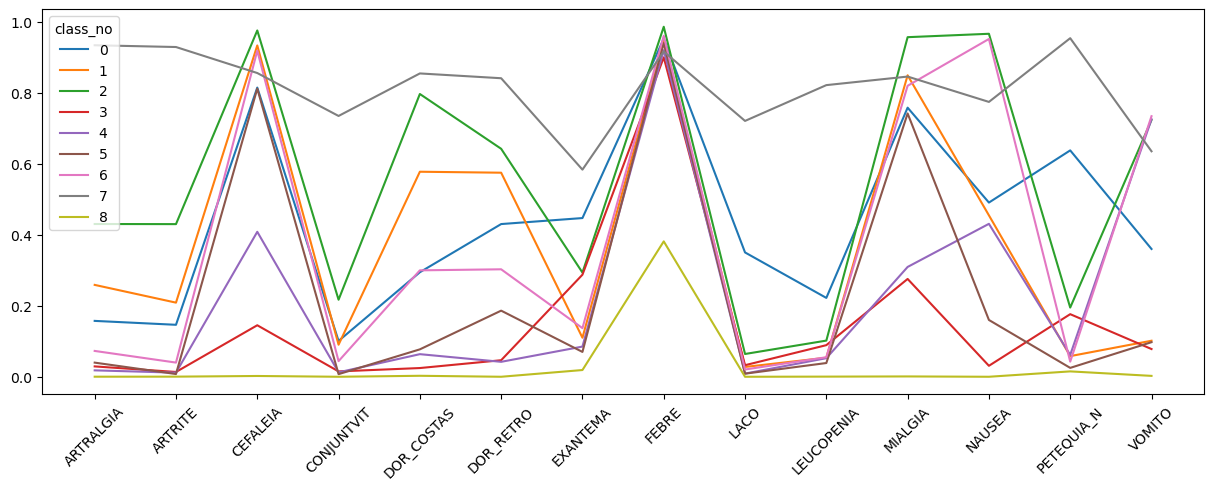

------------------------ predictions ------------------------------


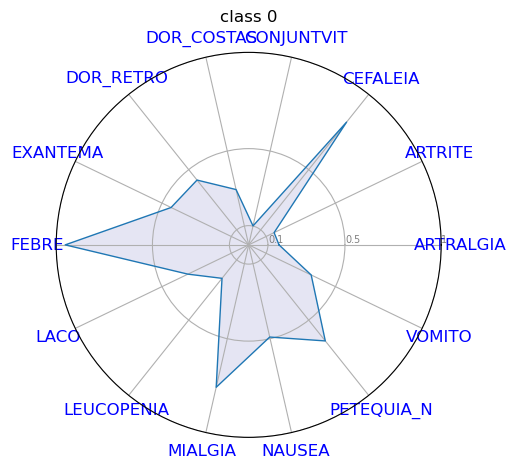

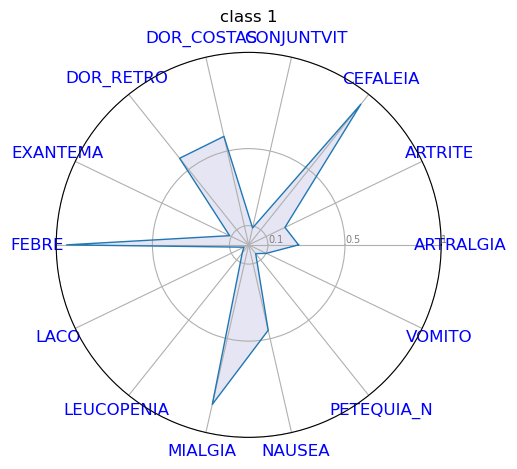

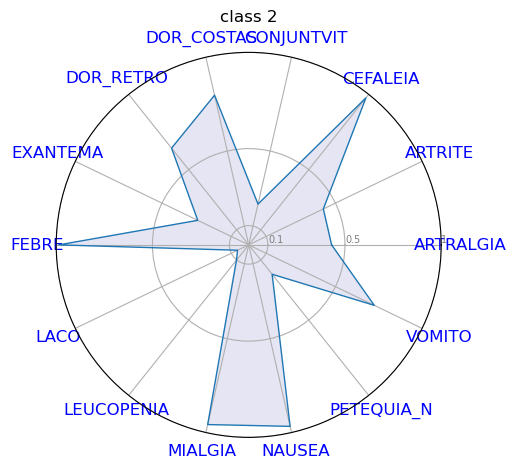

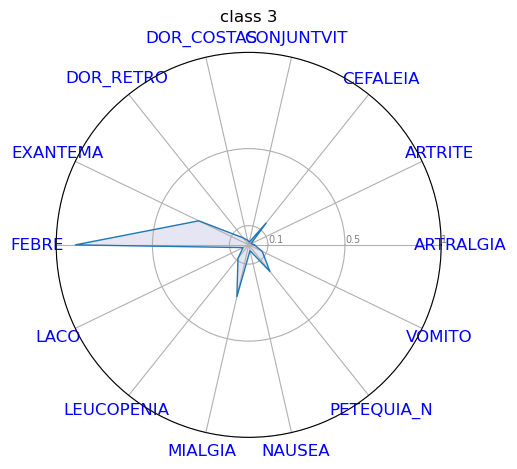

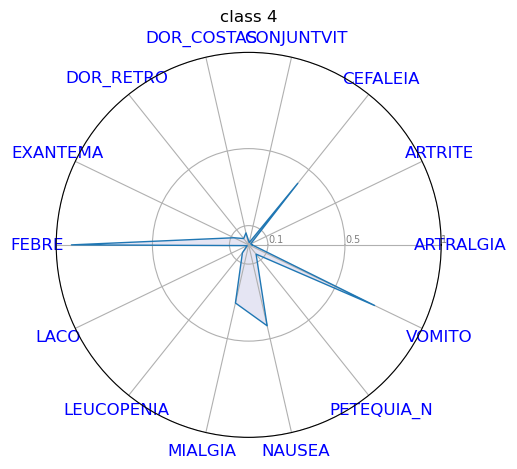

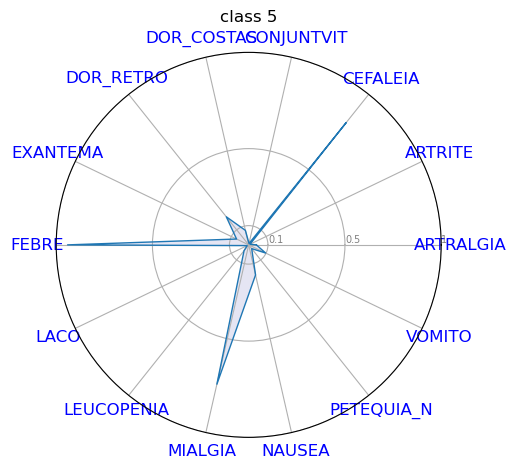

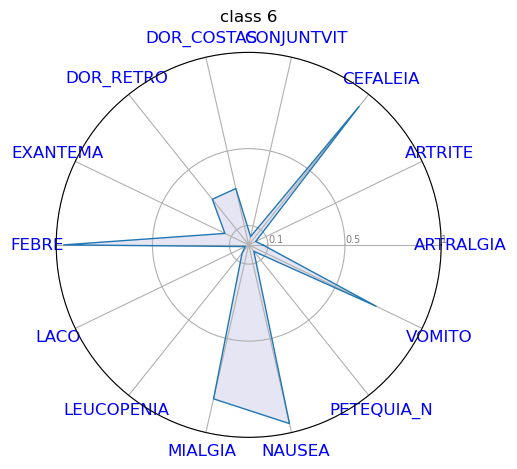

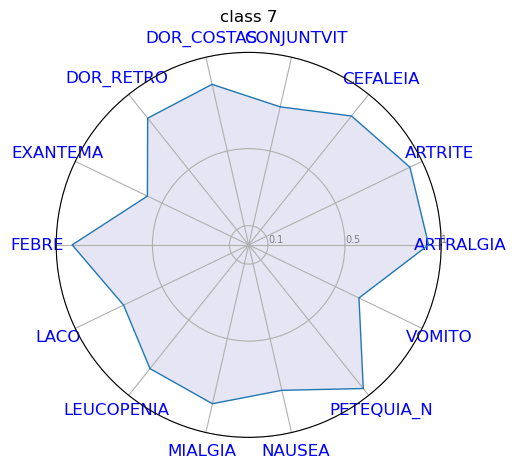

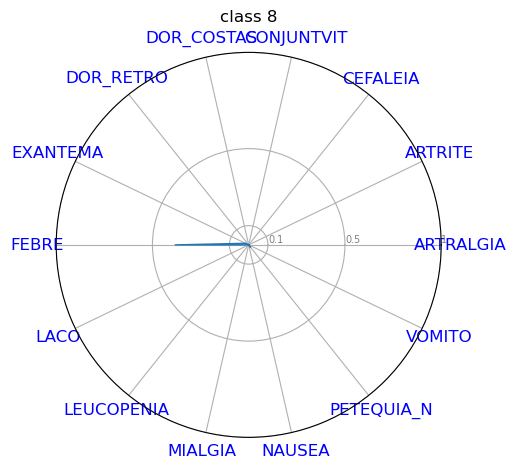

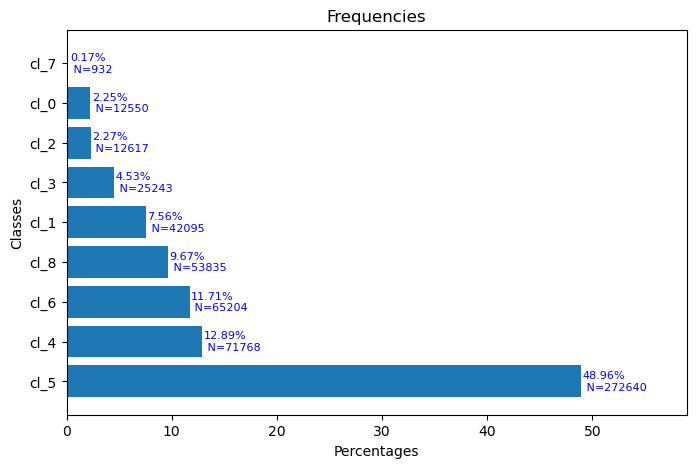

Empty DataFrame
Columns: []
Index: []
======================= LCA with k = 10=========================
MODEL REPORT
    Measurement model parameters
          model_name        binary                                                                        
          class_no               0       1       2       3       4       5       6       7       8       9
          param variable                                                                                  
          pis   ARTRALGIA   0.2640  0.0001  0.1667  0.4277  0.0409  0.0405  0.0288  0.9390  0.0159  0.0801
                ARTRITE     0.1866  0.0001  0.1528  0.4542  0.0857  0.0059  0.0124  0.9284  0.0035  0.0375
                CEFALEIA    0.9549  0.0041  0.8152  0.9759  0.7695  0.8071  0.1601  0.8561  0.3665  0.9163
                CONJUNTVIT  0.0818  0.0000  0.1058  0.2295  0.0562  0.0059  0.0143  0.7383  0.0082  0.0421
                DOR_COSTAS  0.5733  0.0013  0.3008  0.8180  0.4267  0.0575  0.0209  0.8557  0.0168  0.

C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:1224: FutureWarning: The provided callable <function mean at 0x000001D354F6C040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return pd.pivot_table(


<Figure size 2000x800 with 0 Axes>

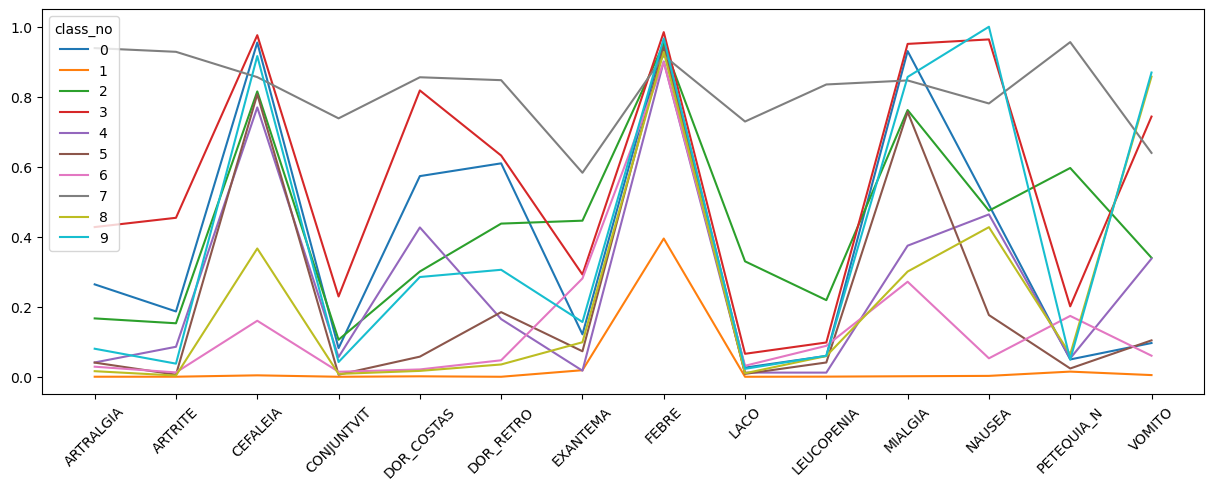

------------------------ predictions ------------------------------


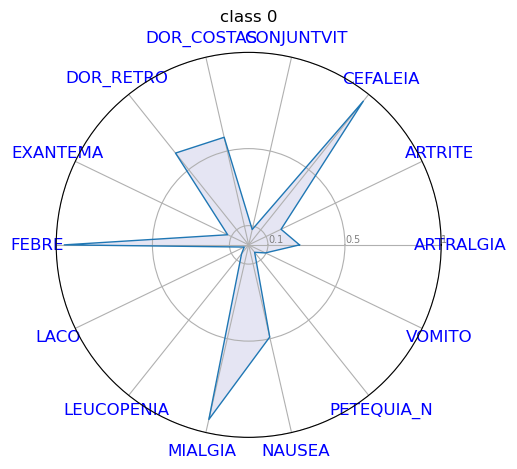

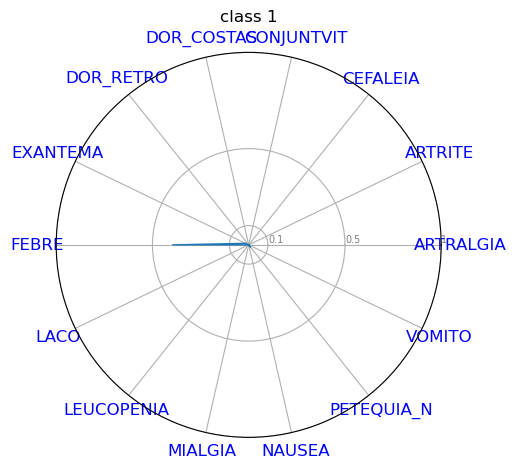

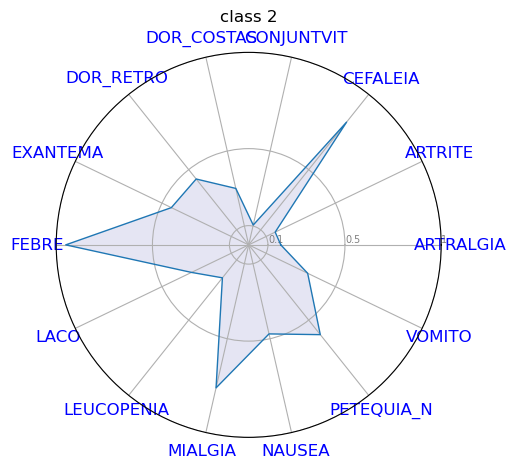

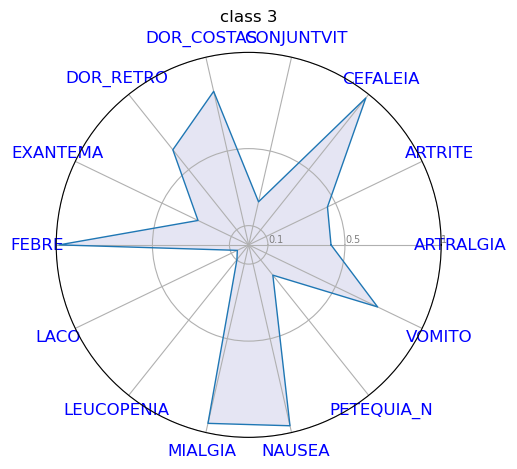

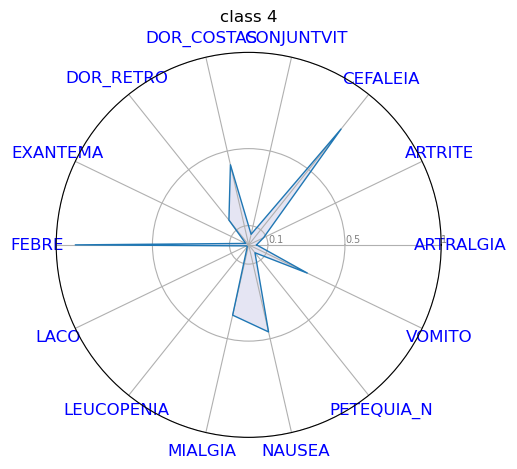

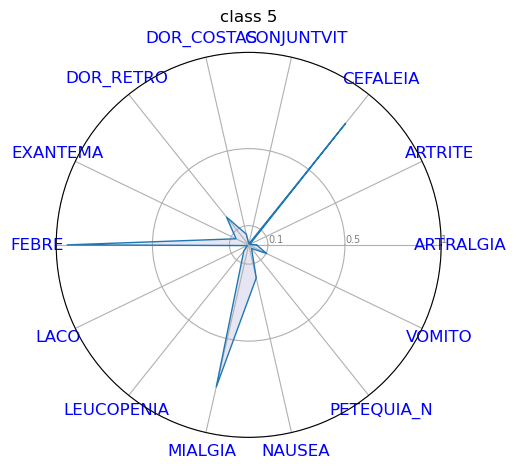

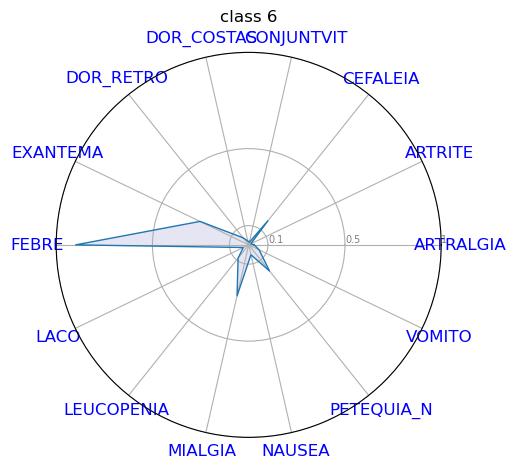

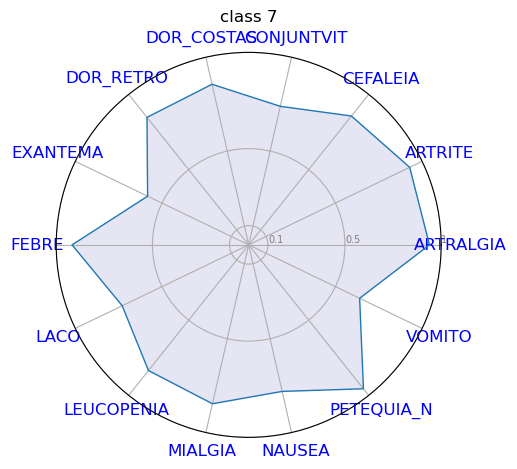

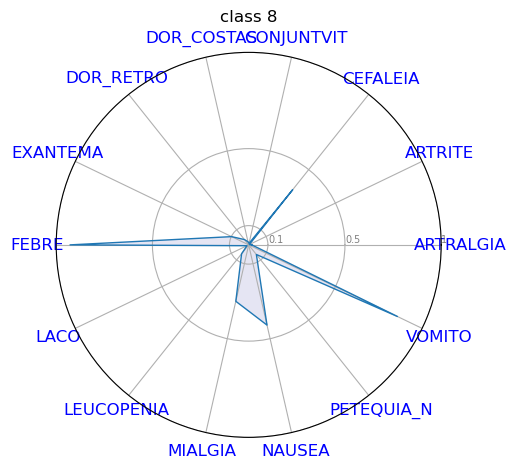

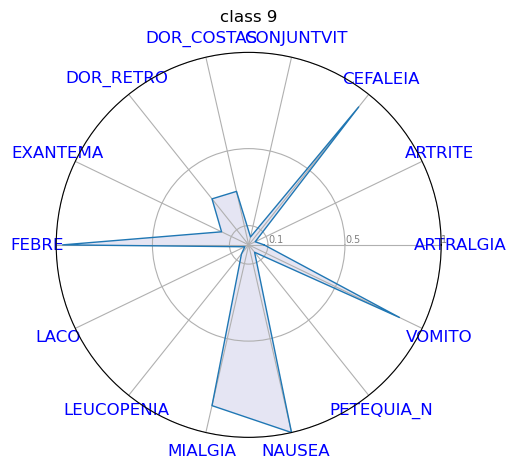

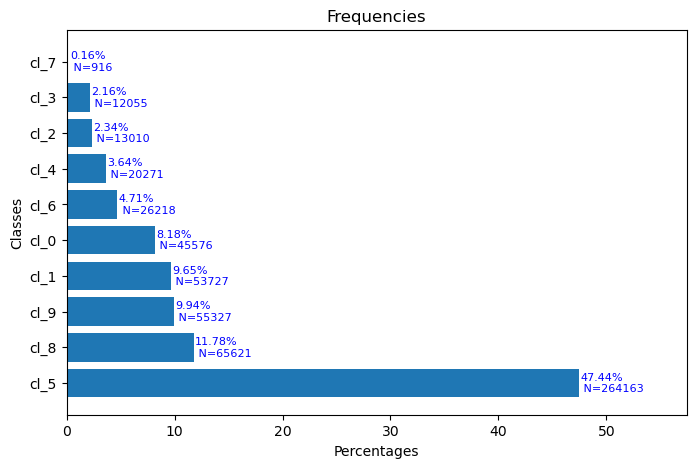

Empty DataFrame
Columns: []
Index: []


In [5]:
for k in [1,2,3,4,6,7,8,9,10]:
    gridS1_15Child.describe_k(k=k,resultsDir=f'./res/childGridS/k_{k}')